# The Bernstein–Vazirani Algorithm — A Hands-On Notebook

### Education Series · Quantum Computing · Trinexis

---

> **Course thesis, restated once more:**
> *Indistinguishable alternatives interfere; probabilities are squared magnitudes of amplitudes.*

Bernstein–Vazirani (BV) is the cleanest illustration of that thesis in the whole algorithms module. A single quantum query, followed by a wall of Hadamards, arranges an **interference pattern** in which every wrong answer cancels and the one correct answer survives with certainty. No parallelism. No luck. Just amplitudes adding and subtracting.

### What you will be able to do after this notebook
1. State precisely the *problem* BV solves and why it is interesting.
2. Explain the mechanism — **phase kickback** + **Hadamard interference** — without hand-waving about "parallel universes."
3. Build BV **from scratch in NumPy** (statevector) and read off the hidden string.
4. Build the **same** algorithm in **Qiskit**, run it on a simulator, and match the two.
5. Work through the **1-, 2-, and 3-qubit** cases explicitly.
6. See what **noise** does to the result, and reason about why.
7. **Play**: change the hidden string, change $n$, and predict the outcome before you run.

---


## 1 · The problem BV solves

Somebody hides a secret bit-string
$$ s = s_0\,s_1\,\dots\,s_{n-1}, \qquad s_i \in \{0,1\}. $$

You are **not** allowed to see $s$. You are only given a black box (an **oracle**) that computes the function
$$ f(x) \;=\; s \cdot x \;=\; \big(s_0 x_0 \oplus s_1 x_1 \oplus \dots \oplus s_{n-1} x_{n-1}\big) \bmod 2, $$
i.e. the bitwise dot product of your query $x$ with the hidden $s$, taken modulo 2.

**Your task:** find $s$ using as few queries to the oracle as possible.

### The classical cost
Query the oracle with the unit strings $e_0 = 100\dots0,\; e_1 = 010\dots0,\;\dots$. Each query reveals exactly one bit:
$$ f(e_i) = s\cdot e_i = s_i. $$
So a classical algorithm needs **$n$ queries** — one per bit. You cannot do better classically: each query returns a single bit of information, and there are $n$ unknown bits.

### The quantum cost
The Bernstein–Vazirani algorithm recovers **all $n$ bits with a single query**. That is the entire point: a query-complexity separation of $n$ versus $1$, achieved deterministically.

> ⚠️ **Misconception to pre-empt:** the speedup is **not** because the quantum computer "tries all $x$ at once." Preparing a uniform superposition is free and, on its own, tells you *nothing* — measuring it just gives a random $x$. The advantage comes entirely from what happens **after** the oracle: the final layer of Hadamards makes the amplitudes **interfere** so that the answer concentrates on $|s\rangle$.


## 2 · Physical intuition — kickback and interference

Two ingredients do all the work. Both should feel familiar from the earlier modules.

### (a) The Hadamard is the Stern–Gerlach $z \leftrightarrow x$ basis change
Recall the SG cascade: sending a $z$-basis state into an $x$-oriented analyser splits it into an equal superposition. The Hadamard gate is exactly that rotation on a single qubit:
$$ H|0\rangle = \tfrac{1}{\sqrt2}\big(|0\rangle+|1\rangle\big)=|+\rangle, \qquad H|1\rangle = \tfrac{1}{\sqrt2}\big(|0\rangle-|1\rangle\big)=|-\rangle. $$
Applied to $n$ qubits, $H^{\otimes n}$ turns $|0\dots0\rangle$ into the uniform superposition over all $2^n$ strings — and, crucially, applied **again**, it turns a specific phase pattern *back* into a single computational-basis state. That second application is the interferometer's recombining beam-splitter.

### (b) Phase kickback puts the answer into the phases
Set the ancilla (output qubit) to $|-\rangle$. A controlled operation that would flip the ancilla when $f(x)=1$ instead does nothing to the ancilla and stamps a **minus sign onto the input**:
$$ |x\rangle\,|-\rangle \;\xrightarrow{\;U_f\;}\; (-1)^{f(x)}\,|x\rangle\,|-\rangle. $$
The ancilla comes out unchanged — the phase is "kicked back" onto the input register. So after one oracle call the input register carries
$$ \frac{1}{\sqrt{2^n}}\sum_{x}(-1)^{\,s\cdot x}\,|x\rangle. $$

### (c) The interference
That state is *precisely* what $H^{\otimes n}$ produces when it acts on $|s\rangle$ — a Hadamard transform is its own inverse, and
$$ H^{\otimes n}\,|s\rangle = \frac{1}{\sqrt{2^n}}\sum_{x}(-1)^{\,s\cdot x}\,|x\rangle. $$
Therefore applying $H^{\otimes n}$ one more time inverts it and lands you on $|s\rangle$ **with probability 1**. Every alternative path to a wrong string $y\neq s$ interferes destructively and cancels. That cancellation *is* the algorithm.


## 3 · The algorithm, step by step

Registers: $n$ **input** qubits (start $|0\rangle^{\otimes n}$) and $1$ **ancilla** (start $|1\rangle$).

| Step | Operation | State of the input register |
|------|-----------|------------------------------|
| 0 | initial | $\lvert 0\rangle^{\otimes n}\,\lvert 1\rangle$ |
| 1 | $H$ on **all** qubits | $\dfrac{1}{\sqrt{2^n}}\sum_x \lvert x\rangle \otimes \lvert-\rangle$ |
| 2 | oracle $U_f$ (kickback) | $\dfrac{1}{\sqrt{2^n}}\sum_x (-1)^{s\cdot x}\lvert x\rangle \otimes \lvert-\rangle$ |
| 3 | $H^{\otimes n}$ on inputs | $\lvert s\rangle \otimes \lvert-\rangle$ |
| 4 | measure inputs | outcome $= s$ (probability 1) |

The whole recipe is: **superpose → kick the answer into the phases → interfere → read it off.**

### The one line of algebra worth memorising
$$ H^{\otimes n}\!\left[\frac{1}{\sqrt{2^n}}\sum_{x}(-1)^{s\cdot x}\lvert x\rangle\right] = \frac{1}{2^n}\sum_{y}\underbrace{\left[\sum_{x}(-1)^{(s\oplus y)\cdot x}\right]}_{=\,2^n\text{ if }y=s,\ \ 0\text{ otherwise}}\lvert y\rangle = \lvert s\rangle. $$
The bracketed sum is a discrete orthogonality relation: it is $2^n$ when $y=s$ and **exactly zero** for every other $y$. That zero is destructive interference, written in one symbol.


## 4 · Setup

Run this once. On Google Colab the `pip install` line grabs the exact versions used to author this notebook. Locally, it is a no-op if you already have them.

In [1]:
# --- Colab / environment setup -------------------------------------------
# Safe to re-run. Installs only if missing.
try:
    import qiskit, qiskit_aer  # noqa
except Exception:
    import sys, subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "qiskit==2.5.0", "qiskit-aer==0.17.2", "pylatexenc"], check=False)

import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

np.random.seed(42)            # reproducibility, fixed across the whole course
plt.rcParams["figure.dpi"] = 110

print("Environment ready.")
try:
    import qiskit, qiskit_aer
    print("qiskit    :", qiskit.__version__)
    print("qiskit-aer:", qiskit_aer.__version__)
except Exception as e:
    print("Qiskit import note:", e)

Environment ready.
qiskit    : 2.5.0
qiskit-aer: 0.17.2


---
## Part A · Build it from scratch in NumPy

Before touching any framework, we implement BV with nothing but state vectors and the Kronecker product. This makes every amplitude visible, so the interference is not hidden inside a library call.

### A.1 · The reusable toolkit
A convention we keep across the course: bit-strings are written **MSB-first** — the leftmost character is bit $s_0$. `int_to_bits(x, n)` therefore returns `[s_0, s_1, ..., s_{n-1}]`.

In [2]:
# ---- toolkit: carried forward, unchanged in spirit, across the series ----

def int_to_bits(x, n):
    """Integer -> length-n bit array, MSB-first: index 0 is the most significant bit."""
    return np.array([(x >> (n - 1 - i)) & 1 for i in range(n)], dtype=int)

def bits_to_str(bits):
    """Bit array -> string, e.g. array([1,0,1]) -> '101'."""
    return "".join(str(int(b)) for b in bits)

def str_to_bits(s):
    """'101' -> array([1,0,1])."""
    return np.array([int(c) for c in s], dtype=int)

def dot_mod2(s_bits, x_bits):
    """The oracle's function f(x) = s . x (mod 2)."""
    return int(np.dot(s_bits, x_bits) % 2)

def hadamard_n(n):
    """H^{⊗n} as a dense 2^n x 2^n matrix, built by repeated Kronecker product."""
    H = (1 / np.sqrt(2)) * np.array([[1.0, 1.0], [1.0, -1.0]])
    M = np.array([[1.0]])
    for _ in range(n):
        M = np.kron(M, H)
    return M

def bv_oracle_phase(s_bits):
    """Phase-kickback oracle as a diagonal: entry x is (-1)^(s . x).

    This is the whole oracle once the ancilla is in |->: it multiplies the
    amplitude of |x> by (-1)^(s.x). Returned as a length-2^n vector of ±1.
    """
    n = len(s_bits)
    N = 2 ** n
    return np.array([(-1) ** dot_mod2(s_bits, int_to_bits(x, n)) for x in range(N)],
                    dtype=float)

print("Toolkit loaded:",
      "int_to_bits, bits_to_str, str_to_bits, dot_mod2, hadamard_n, bv_oracle_phase")

Toolkit loaded: int_to_bits, bits_to_str, str_to_bits, dot_mod2, hadamard_n, bv_oracle_phase


In [3]:
def run_bv_numpy(s_bits, verbose=False):
    """Full BV run on the input register (ancilla folded into phase kickback).

    Returns a dict with the amplitudes at each stage so we can *see* the
    interference, plus the recovered string.
    """
    n = len(s_bits)
    N = 2 ** n
    Hn = hadamard_n(n)

    psi0 = np.zeros(N); psi0[0] = 1.0        # |00...0>
    psi1 = Hn @ psi0                          # step 1: uniform superposition
    psi2 = bv_oracle_phase(s_bits) * psi1     # step 2: phase kickback
    psi3 = Hn @ psi2                          # step 3: interfere back

    probs = np.abs(psi3) ** 2
    recovered = int_to_bits(int(np.argmax(probs)), n)

    if verbose:
        print(f"hidden s      = {bits_to_str(s_bits)}")
        print(f"after oracle  = {np.round(psi2, 3)}   (phases carry s)")
        print(f"final probs   = {np.round(probs, 3)}")
        print(f"recovered s   = {bits_to_str(recovered)}  "
              f"(peak probability = {probs.max():.3f})")
    return dict(psi1=psi1, psi2=psi2, psi3=psi3, probs=probs, recovered=recovered)

# quick smoke test
_ = run_bv_numpy(str_to_bits("101"), verbose=True)

hidden s      = 101
after oracle  = [ 0.354 -0.354  0.354 -0.354 -0.354  0.354 -0.354  0.354]   (phases carry s)
final probs   = [0. 0. 0. 0. 0. 1. 0. 0.]
recovered s   = 101  (peak probability = 1.000)


### A.2 · The 1-qubit case ($n=1$)

The smallest non-trivial instance. There are only two possible secrets, $s=0$ and $s=1$. With one qubit the "interference" is a single beam-splitter recombination, but it already gives the deterministic answer.

In [4]:
print("=== 1-QUBIT BERNSTEIN-VAZIRANI ===\n")
for s in ["0", "1"]:
    r = run_bv_numpy(str_to_bits(s))
    print(f"hidden s = {s}   ->   recovered = {bits_to_str(r['recovered'])}   "
          f"| P(correct) = {r['probs'].max():.3f}")

=== 1-QUBIT BERNSTEIN-VAZIRANI ===

hidden s = 0   ->   recovered = 0   | P(correct) = 1.000
hidden s = 1   ->   recovered = 1   | P(correct) = 1.000


### Visualising the interference

The bar chart below shows the amplitudes on each basis string **just before** and **just after** the final Hadamard layer. Before: the sign pattern is spread across all strings. After: everything cancels except $|s\rangle$, which reaches amplitude $1$. That collapse-by-cancellation is the algorithm working.

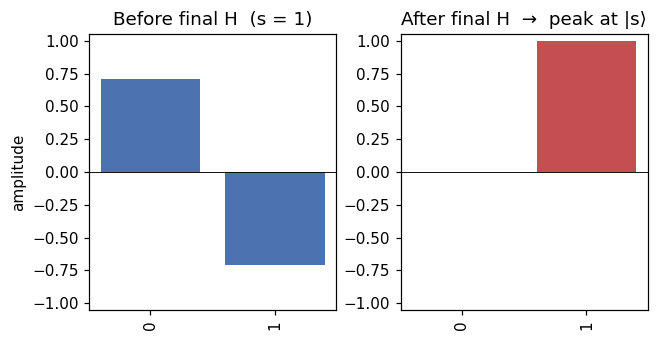

In [5]:
def plot_interference(s_bits, ax_pair=None):
    """Amplitudes before vs after the final Hadamard layer."""
    n = len(s_bits)
    N = 2 ** n
    r = run_bv_numpy(s_bits)
    labels = [format(x, f"0{n}b") for x in range(N)]

    if ax_pair is None:
        fig, ax_pair = plt.subplots(1, 2, figsize=(max(6, 1.1 * N), 3.2))
    a0, a1 = ax_pair
    a0.bar(labels, r["psi2"], color="#4C72B0")
    a0.set_title(f"Before final H  (s = {bits_to_str(s_bits)})")
    a0.set_ylabel("amplitude"); a0.axhline(0, color="k", lw=0.6)
    a0.set_ylim(-1.05, 1.05); a0.tick_params(axis="x", rotation=90)

    a1.bar(labels, r["psi3"], color="#C44E52")
    a1.set_title("After final H  →  peak at |s⟩")
    a1.axhline(0, color="k", lw=0.6)
    a1.set_ylim(-1.05, 1.05); a1.tick_params(axis="x", rotation=90)
    plt.tight_layout()
    return r

_ = plot_interference(str_to_bits("1"))
plt.show()

### A.3 · The 2-qubit case ($n=2$)

Now four possible secrets: $00, 01, 10, 11$. Watch how the *pattern* of $\pm$ signs after the oracle is different for each secret, yet the final Hadamard always concentrates all the probability on the correct $|s\rangle$.

=== 2-QUBIT BERNSTEIN-VAZIRANI ===

hidden s = 00   ->   recovered = 00   | P(correct) = 1.000
hidden s = 01   ->   recovered = 01   | P(correct) = 1.000
hidden s = 10   ->   recovered = 10   | P(correct) = 1.000
hidden s = 11   ->   recovered = 11   | P(correct) = 1.000


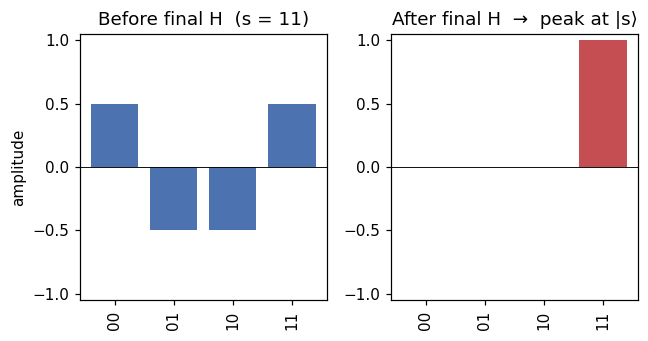

In [6]:
print("=== 2-QUBIT BERNSTEIN-VAZIRANI ===\n")
for s in ["00", "01", "10", "11"]:
    r = run_bv_numpy(str_to_bits(s))
    print(f"hidden s = {s}   ->   recovered = {bits_to_str(r['recovered'])}   "
          f"| P(correct) = {r['probs'].max():.3f}")

# interference picture for one representative secret
_ = plot_interference(str_to_bits("11"))
plt.show()

### A.4 · The 3-qubit case ($n=3$)

Eight possible secrets. Classically this needs **3** queries; BV needs **1**. Below we sweep all eight and confirm each is recovered with certainty, then draw the interference for one of them.

=== 3-QUBIT BERNSTEIN-VAZIRANI ===

hidden s = 000   ->   recovered = 000   | P(correct) = 1.000   OK
hidden s = 001   ->   recovered = 001   | P(correct) = 1.000   OK
hidden s = 010   ->   recovered = 010   | P(correct) = 1.000   OK
hidden s = 011   ->   recovered = 011   | P(correct) = 1.000   OK
hidden s = 100   ->   recovered = 100   | P(correct) = 1.000   OK
hidden s = 101   ->   recovered = 101   | P(correct) = 1.000   OK
hidden s = 110   ->   recovered = 110   | P(correct) = 1.000   OK
hidden s = 111   ->   recovered = 111   | P(correct) = 1.000   OK

All eight 3-qubit secrets recovered deterministically: True


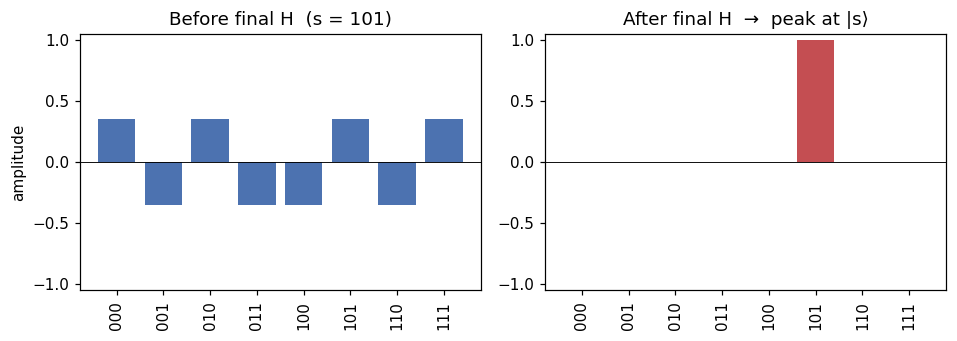

In [7]:
print("=== 3-QUBIT BERNSTEIN-VAZIRANI ===\n")
all_ok = True
for x in range(8):
    s = format(x, "03b")
    r = run_bv_numpy(str_to_bits(s))
    ok = bits_to_str(r["recovered"]) == s and abs(r["probs"].max() - 1) < 1e-12
    all_ok &= ok
    print(f"hidden s = {s}   ->   recovered = {bits_to_str(r['recovered'])}   "
          f"| P(correct) = {r['probs'].max():.3f}   {'OK' if ok else 'FAIL'}")
print(f"\nAll eight 3-qubit secrets recovered deterministically: {all_ok}")

_ = plot_interference(str_to_bits("101"))
plt.show()

### A.5 · Classical vs quantum: counting the queries

To make the separation concrete, here is the honest classical algorithm — probe with one unit string per bit — alongside the quantum query count of exactly **one**.

In [8]:
def classical_bv(oracle, n):
    """Recover s classically. One query per bit -> n queries total."""
    s = []
    for i in range(n):
        e_i = np.zeros(n, dtype=int); e_i[i] = 1
        s.append(oracle(e_i))          # f(e_i) = s_i
    return np.array(s), n              # (recovered, #queries)

print(f"{'n':>2} | {'secret':>8} | {'classical queries':>17} | {'quantum queries':>15}")
print("-" * 52)
for n in [1, 2, 3]:
    s_bits = int_to_bits(0b110 % (2 ** n), n)
    oracle = lambda x, sb=s_bits: dot_mod2(sb, x)
    rec, q_classical = classical_bv(oracle, n)
    assert bits_to_str(rec) == bits_to_str(s_bits)
    print(f"{n:>2} | {bits_to_str(s_bits):>8} | {q_classical:>17} | {1:>15}")

print("\nClassical cost grows with n; quantum cost stays at 1. That gap is the point.")

 n |   secret | classical queries | quantum queries
----------------------------------------------------
 1 |        0 |                 1 |               1
 2 |       10 |                 2 |               1
 3 |      110 |                 3 |               1

Classical cost grows with n; quantum cost stays at 1. That gap is the point.


---
## Part B · The same algorithm in Qiskit

Now we build the *actual circuit* with an explicit ancilla, run it on the Aer simulator with measurement shots, and confirm it agrees with the from-scratch NumPy version.

### B.1 · The circuit builder

**Endianness discipline (important, and a classic source of bugs).** Qiskit numbers its measurement strings **little-endian**: the leftmost character of a counts key is the *highest-index* qubit. We keep our course convention that hidden strings are **MSB-first** (`s_bits[0]` is the most significant bit). So we place `s_bits[i]` on qubit `i`, and when reading a counts key we **reverse** it — string index `k` corresponds to qubit `n-1-k`. After reversing, the printed outcome matches the hidden string character-for-character.

In [21]:
def bv_circuit(s_bits, barriers=True):
    """Bernstein-Vazirani circuit for hidden string s_bits (MSB-first).

    n input qubits (0..n-1) + 1 ancilla (qubit n). Oracle = a CX from input
    qubit i to the ancilla for every i with s_i = 1  (that's f(x) = s.x).
    """
    n = len(s_bits)
    qc = QuantumCircuit(n + 1, n)

    qc.x(n)                     # ancilla -> |1>
    qc.h(range(n + 1))          # H on inputs AND ancilla (ancilla becomes |->)
    if barriers: qc.barrier()

    for i in range(n):          # --- the oracle U_f ---
        if s_bits[i] == 1:
            qc.cx(i, n)         # kickback: stamps (-1)^(x_i) when s_i = 1
    if barriers: qc.barrier()

    qc.h(range(n))              # final Hadamards on the input register only
    qc.measure(range(n), range(n))
    return qc

def recover_from_counts(counts, n):
    """Most-frequent outcome, reversed to MSB-first to match our convention."""
    top = max(counts, key=counts.get)
    return top[::-1]            # string index k <-> qubit n-1-k

# show the structure for s = 101
demo = bv_circuit(str_to_bits("101"))
print(demo.draw(output="text"))

     ┌───┐      ░            ░ ┌───┐┌─┐      
q_0: ┤ H ├──────░───■────────░─┤ H ├┤M├──────
     ├───┤      ░   │        ░ ├───┤└╥┘┌─┐   
q_1: ┤ H ├──────░───┼────────░─┤ H ├─╫─┤M├───
     ├───┤      ░   │        ░ ├───┤ ║ └╥┘┌─┐
q_2: ┤ H ├──────░───┼────■───░─┤ H ├─╫──╫─┤M├
     ├───┤┌───┐ ░ ┌─┴─┐┌─┴─┐ ░ └───┘ ║  ║ └╥┘
q_3: ┤ X ├┤ H ├─░─┤ X ├┤ X ├─░───────╫──╫──╫─
     └───┘└───┘ ░ └───┘└───┘ ░       ║  ║  ║ 
c: 3/════════════════════════════════╩══╩══╩═
                                     0  1  2 


### B.2 · Run all three sizes on the simulator

We run each case with 1024 shots. Because BV is deterministic, an ideal simulator puts **100% of the shots** on the correct string.

In [10]:
sim = AerSimulator()

def run_bv_qiskit(s_str, shots=1024, draw=False):
    s_bits = str_to_bits(s_str)
    n = len(s_bits)
    qc = bv_circuit(s_bits, barriers=True)
    tqc = transpile(qc, sim)
    counts = sim.run(tqc, shots=shots).result().get_counts()
    recovered = recover_from_counts(counts, n)
    if draw:
        print(qc.draw(output="text"))
    return counts, recovered

print("=== Qiskit BV: 1, 2, and 3 qubits ===\n")
for group in [["0", "1"], ["00", "01", "10", "11"],
              ["000", "011", "101", "110", "111"]]:
    n = len(group[0])
    print(f"--- n = {n} ---")
    for s in group:
        counts, rec = run_bv_qiskit(s)
        frac = counts.get(s[::-1], 0) / sum(counts.values())
        print(f"  hidden {s}  ->  recovered {rec}  |  P(correct) = {frac:.3f}")
    print()

=== Qiskit BV: 1, 2, and 3 qubits ===

--- n = 1 ---
  hidden 0  ->  recovered 0  |  P(correct) = 1.000
  hidden 1  ->  recovered 1  |  P(correct) = 1.000

--- n = 2 ---
  hidden 00  ->  recovered 00  |  P(correct) = 1.000
  hidden 01  ->  recovered 01  |  P(correct) = 1.000
  hidden 10  ->  recovered 10  |  P(correct) = 1.000
  hidden 11  ->  recovered 11  |  P(correct) = 1.000

--- n = 3 ---
  hidden 000  ->  recovered 000  |  P(correct) = 1.000
  hidden 011  ->  recovered 011  |  P(correct) = 1.000
  hidden 101  ->  recovered 101  |  P(correct) = 1.000
  hidden 110  ->  recovered 110  |  P(correct) = 1.000
  hidden 111  ->  recovered 111  |  P(correct) = 1.000



### B.3 · A measurement histogram

A histogram makes the determinism visually obvious: a single bar for the hidden string, nothing anywhere else.

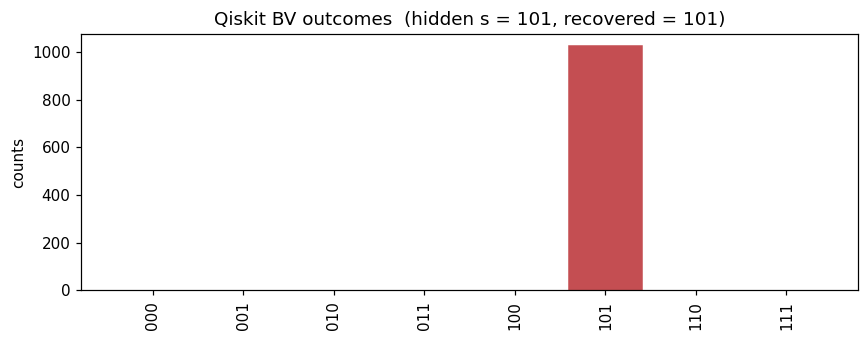

In [11]:
def plot_counts(s_str, shots=1024):
    counts, rec = run_bv_qiskit(s_str, shots=shots)
    n = len(s_str)
    # relabel keys to MSB-first for readability
    labeled = {k[::-1]: v for k, v in counts.items()}
    keys = [format(x, f"0{n}b") for x in range(2 ** n)]
    vals = [labeled.get(k, 0) for k in keys]
    plt.figure(figsize=(max(5, 1.0 * 2 ** n), 3.2))
    bars = plt.bar(keys, vals, color="#55A868")
    for k, b in zip(keys, bars):
        if k == s_str:
            b.set_color("#C44E52")
    plt.title(f"Qiskit BV outcomes  (hidden s = {s_str}, recovered = {rec})")
    plt.ylabel("counts"); plt.xticks(rotation=90); plt.tight_layout()
    plt.show()

plot_counts("101")

### B.4 · Cross-check: Qiskit vs NumPy

Good practice we follow throughout the course — never trust a single implementation. We confirm the two independent builds agree on every secret up to $n=3$.

In [12]:
print("Cross-checking Qiskit against the NumPy statevector build...\n")
all_match = True
for n in [1, 2, 3]:
    for x in range(2 ** n):
        s = format(x, f"0{n}b")
        _, rec_q = run_bv_qiskit(s, shots=512)
        rec_np = bits_to_str(run_bv_numpy(str_to_bits(s))["recovered"])
        match = (rec_q == rec_np == s)
        all_match &= match
        if not match:
            print(f"  MISMATCH n={n} s={s}: qiskit={rec_q} numpy={rec_np}")
print(f"All secrets for n = 1, 2, 3 agree across both builds: {all_match}")

Cross-checking Qiskit against the NumPy statevector build...

All secrets for n = 1, 2, 3 agree across both builds: True


---
## Part C · What noise does (enrichment)

Real devices are noisy. BV is deterministic *in theory*; on hardware the single-shot certainty degrades. Here we add a depolarising error to every gate and watch the correct string lose its monopoly — the answer is still the **most likely** outcome, but wrong strings start collecting probability.

This is also a teaching moment for the decoherence / which-path theme from the noise module: each faulty gate slightly scrambles the phase relationships the interference depends on.

hidden s = 101
  ideal  success probability : 1.000
  noisy  success probability : 0.810  (5% depolarising per gate)


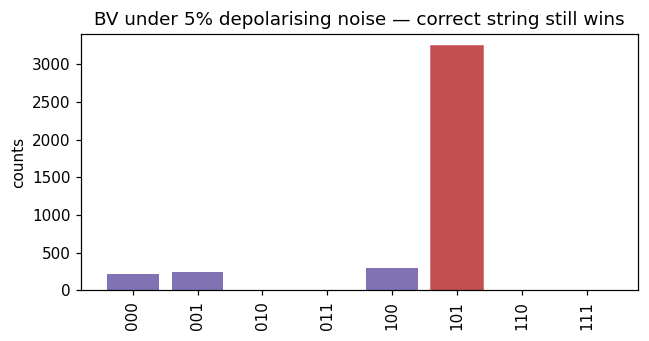

In [13]:
from qiskit_aer.noise import NoiseModel, depolarizing_error

def noisy_simulator(p1=0.03, p2=0.03):
    nm = NoiseModel()
    nm.add_all_qubit_quantum_error(depolarizing_error(p1, 1), ["h", "x"])
    nm.add_all_qubit_quantum_error(depolarizing_error(p2, 2), ["cx"])
    return AerSimulator(noise_model=nm)

def bv_success_prob(s_str, sim_backend, shots=4000):
    s_bits = str_to_bits(s_str)
    qc = bv_circuit(s_bits, barriers=False)
    counts = sim_backend.run(transpile(qc, sim_backend), shots=shots).result().get_counts()
    return counts.get(s_str[::-1], 0) / shots, counts

s = "101"
p_ideal, _ = bv_success_prob(s, AerSimulator())
p_noisy, counts_noisy = bv_success_prob(s, noisy_simulator(0.05, 0.05))
print(f"hidden s = {s}")
print(f"  ideal  success probability : {p_ideal:.3f}")
print(f"  noisy  success probability : {p_noisy:.3f}  (5% depolarising per gate)")

labeled = {k[::-1]: v for k, v in counts_noisy.items()}
keys = [format(x, "03b") for x in range(8)]
vals = [labeled.get(k, 0) for k in keys]
plt.figure(figsize=(6, 3.2))
bars = plt.bar(keys, vals, color="#8172B3")
for k, b in zip(keys, bars):
    if k == s: b.set_color("#C44E52")
plt.title("BV under 5% depolarising noise — correct string still wins")
plt.ylabel("counts"); plt.xticks(rotation=90); plt.tight_layout(); plt.show()

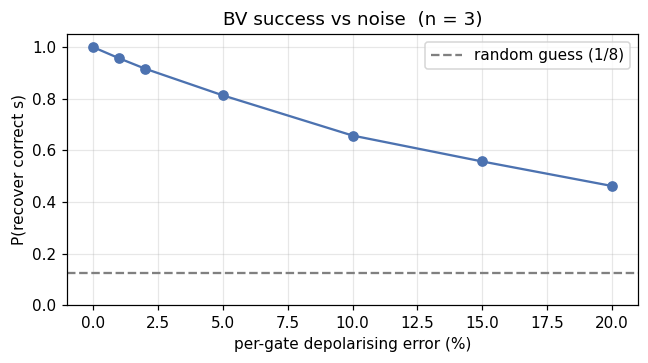

In [14]:
# How does success degrade as noise increases?  (n = 3, s = 110)
levels = [0.0, 0.01, 0.02, 0.05, 0.10, 0.15, 0.20]
probs = []
for p in levels:
    backend = AerSimulator() if p == 0 else noisy_simulator(p, p)
    pr, _ = bv_success_prob("110", backend, shots=4000)
    probs.append(pr)

plt.figure(figsize=(6, 3.4))
plt.plot([100 * p for p in levels], probs, "o-", color="#4C72B0")
plt.axhline(1 / 8, ls="--", color="gray", label="random guess (1/8)")
plt.xlabel("per-gate depolarising error (%)"); plt.ylabel("P(recover correct s)")
plt.title("BV success vs noise  (n = 3)"); plt.ylim(0, 1.05)
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

---
## Part D · Exercises

Difficulty: ★ (warm-up) → ★★★★ (challenge). The stubs deliberately return **wrong placeholder values** so an unfinished exercise shows an obvious failure rather than silently "passing." Replace the `TODO` lines. A solution outline is folded under each block — open it only after trying.

Run the setup and toolkit cells above first.

### Exercise 1 ★ — Predict before you run
Without executing anything, write down the measurement outcome you expect for the hidden string `s = "110"` on a 3-qubit ideal BV circuit. Then check with `run_bv_qiskit("110")`.

<details><summary>💡 Solution</summary>

The outcome is `110` with probability 1. BV is deterministic on an ideal simulator, so a single shot already reveals the whole string. `run_bv_qiskit("110")` returns counts `{'011': ...}` (Qiskit's little-endian key) which reverses to `110`.
</details>


In [15]:
# Exercise 2 ★★ — Build the oracle yourself.
# Return the diagonal phase vector (length 2^n) implementing (-1)^(s . x),
# WITHOUT calling bv_oracle_phase. Use int_to_bits and dot_mod2.

def my_oracle_phase(s_bits):
    n = len(s_bits)
    N = 2 ** n
    phases = np.ones(N)
    # TODO: replace the line below so phases[x] = (-1)^(s . x)
    phases[:] = -999.0          # <- obviously wrong placeholder
    return phases

# --- checker (do not edit) ---
def _check_ex2():
    for s in ["1", "01", "101", "110"]:
        sb = str_to_bits(s)
        if not np.allclose(my_oracle_phase(sb), bv_oracle_phase(sb)):
            return False
    return True
print("Exercise 2:", "PASS ✅" if _check_ex2() else "not yet — fix the TODO ❌")

Exercise 2: not yet — fix the TODO ❌


<details><summary>💡 Solution — Exercise 2</summary>

```python
for x in range(N):
    phases[x] = (-1) ** dot_mod2(s_bits, int_to_bits(x, n))
```
This is exactly the phase kickback: amplitude of $|x\rangle$ is multiplied by $(-1)^{s\cdot x}$.
</details>


In [16]:
# Exercise 3 ★★★ — Recover s from a "mystery" oracle you are not allowed to read.
# The mystery oracle is given ONLY as its diagonal phase vector.
# Build a BV-style routine that recovers s using the from-scratch machinery.

def make_mystery(n, seed):
    rng = np.random.default_rng(seed)
    s_bits = rng.integers(0, 2, size=n)
    return bv_oracle_phase(s_bits), s_bits    # you may use the phase vector, NOT s_bits

def recover_secret(phase_vec):
    n = int(np.log2(len(phase_vec)))
    Hn = hadamard_n(n)
    N = 2 ** n
    # TODO: apply H^n to |0..0>, multiply by phase_vec, apply H^n again,
    #       then read off the peak. Return the recovered bit-string (np.array).
    return np.zeros(n, dtype=int)   # <- placeholder, always wrong for s != 0

# --- checker ---
def _check_ex3():
    ok = True
    for seed in range(6):
        for n in [1, 2, 3]:
            phase_vec, s_true = make_mystery(n, seed * 10 + n)
            if bits_to_str(recover_secret(phase_vec)) != bits_to_str(s_true):
                ok = False
    return ok
print("Exercise 3:", "PASS ✅" if _check_ex3() else "not yet — fix the TODO ❌")

Exercise 3: not yet — fix the TODO ❌


<details><summary>💡 Solution — Exercise 3</summary>

```python
psi = np.zeros(N); psi[0] = 1.0
psi = Hn @ psi              # uniform superposition
psi = phase_vec * psi      # apply the mystery oracle
psi = Hn @ psi             # interfere
return int_to_bits(int(np.argmax(np.abs(psi) ** 2)), n)
```
You never looked at `s_true` — the interference handed it to you.
</details>


In [17]:
# Exercise 4 ★★★★ — Robustness by majority vote.
# Under noise a single shot can be wrong. Show that taking the MOST FREQUENT
# outcome over many shots restores reliability even at moderate noise.
# Complete majority_recover so it returns the reversed (MSB-first) top string.

def majority_recover(s_str, per_gate_error=0.08, shots=2000):
    backend = noisy_simulator(per_gate_error, per_gate_error)
    qc = bv_circuit(str_to_bits(s_str), barriers=False)
    counts = backend.run(transpile(qc, backend), shots=shots).result().get_counts()
    # TODO: return the MSB-first most-frequent outcome
    return "?" * len(s_str)      # <- placeholder

def _check_ex4():
    good = 0
    for s in ["101", "110", "011", "111"]:
        if majority_recover(s) == s:
            good += 1
    return good == 4
print("Exercise 4:", "PASS ✅" if _check_ex4() else "not yet — fix the TODO ❌")

Exercise 4: not yet — fix the TODO ❌


<details><summary>💡 Solution — Exercise 4</summary>

```python
top = max(counts, key=counts.get)
return top[::-1]
```
Even when individual shots are corrupted, the correct string remains the *mode* for moderate noise, so majority voting recovers it. This is the seed of the idea behind repetition and, later, error correction.
</details>


---
## Part E · Play with it yourself

Everything is parametrised by a single string. To experiment:

1. Change `HIDDEN` below to any bit-string you like — e.g. `"1"`, `"0110"`, `"10101"`.
2. Re-run the cell. It runs **both** the NumPy and Qiskit builds and draws the interference and the histogram.
3. Try to **predict the outcome before running.** For BV you should always be able to.

Questions to chew on while you play:
- What happens to the interference picture as you flip one bit of `HIDDEN`?
- Why does the all-zeros secret `"000"` still work — what does the oracle do then?
- At what noise level does the histogram stop having a clear winner?

Hidden string : 1011   (n = 4 input qubits)

hidden s      = 1011
after oracle  = [ 0.25 -0.25 -0.25  0.25  0.25 -0.25 -0.25  0.25 -0.25  0.25  0.25 -0.25
 -0.25  0.25  0.25 -0.25]   (phases carry s)
final probs   = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
recovered s   = 1011  (peak probability = 1.000)

Qiskit recovered : 1011   (matches NumPy: True)


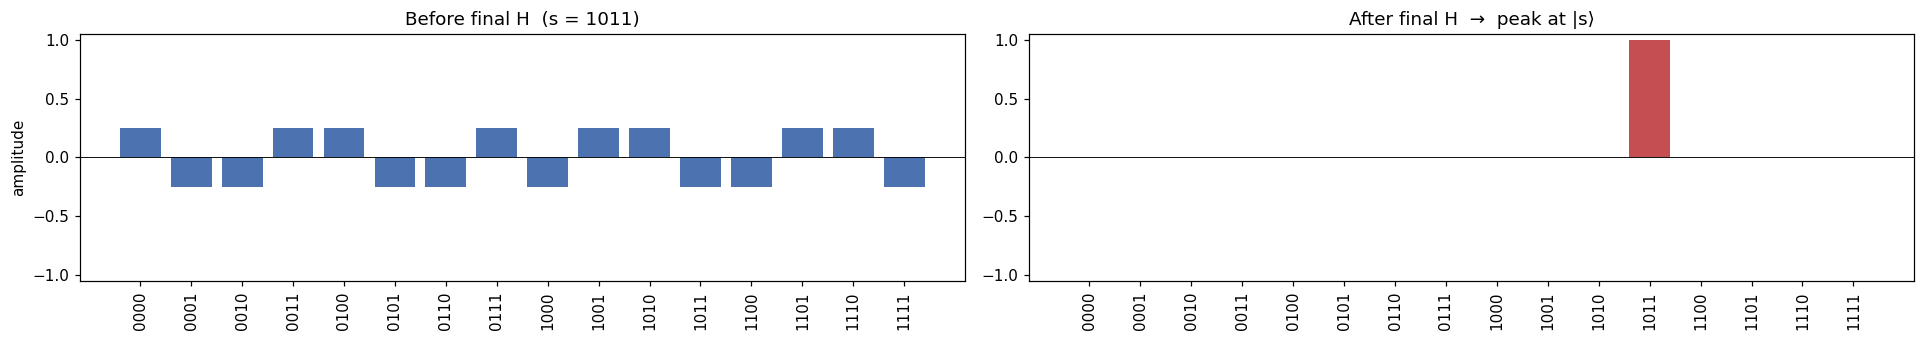

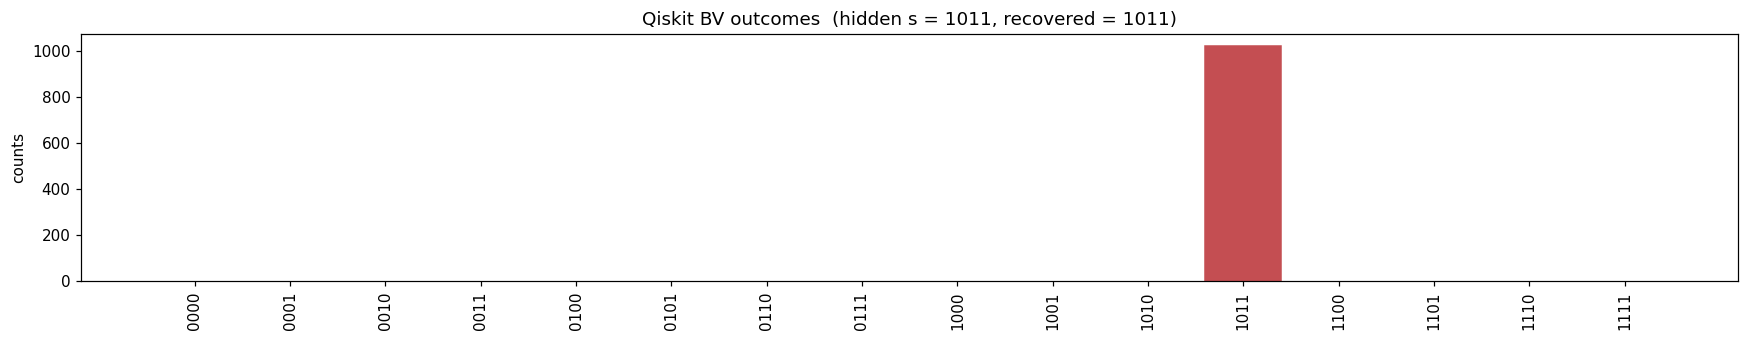

In [18]:
HIDDEN = "1011"          # <-- edit me and re-run

s_bits = str_to_bits(HIDDEN)
n = len(s_bits)
print(f"Hidden string : {HIDDEN}   (n = {n} input qubits)\n")

# NumPy build
rnp = run_bv_numpy(s_bits, verbose=True)
print()

# Qiskit build
counts, rec_q = run_bv_qiskit(HIDDEN, shots=1024)
print(f"Qiskit recovered : {rec_q}   (matches NumPy: {rec_q == bits_to_str(rnp['recovered'])})")

# pictures
_ = plot_interference(s_bits); plt.show()
plot_counts(HIDDEN)

---
## Summary — what to take away

- **The problem:** find a hidden $n$-bit string $s$ given only an oracle for $f(x)=s\cdot x \pmod 2$.
- **Classical cost:** $n$ queries. **Quantum cost:** $1$ query, deterministically.
- **The mechanism, in one sentence:** Hadamards create a superposition, **phase kickback** writes $s$ into the *signs* of the amplitudes, and a second layer of Hadamards makes every wrong answer **interfere destructively**, leaving $|s\rangle$ with certainty.
- **Not parallelism.** A bare superposition carries no advantage; measuring it gives noise. The advantage is the engineered **interference** after the oracle. This is the same physics as the double-slit and the SG cascade, dressed as a computation.
- **Noise** blurs the interference but the correct string stays the most probable outcome for moderate error rates.

### Where this sits in the course
BV is the middle sibling of a family built on the same idea:
- **Deutsch–Jozsa** — decide *one global property* (constant vs balanced) with one query; same kickback + interference skeleton.
- **Bernstein–Vazirani** — extract a *full linear structure* $s$ with one query (this notebook).
- **Simon's algorithm** — extract a *hidden period* and needs entanglement + classical post-processing; the natural next step, and the conceptual bridge to Shor.

Every one of them is the course thesis in action: *indistinguishable alternatives interfere; probabilities are squared magnitudes of amplitudes.*
